# 실습 2. Bagging과 Random Forest

## 데이터
- 데이터셋: `sklearn.datasets.load_breast_cancer()`
- 데이터 내용: 유방암 진단에 사용되는 종양의 반지름, 질감, 면적, 오목도 등 수치 feature
- target: 종양 진단 결과
  - `0`: malignant, 악성
  - `1`: benign, 양성

## 실습 목표
- bootstrap sampling과 OOB 샘플을 직접 확인
- 단일 결정트리와 BaggingClassifier 성능 비교
- RandomForestClassifier의 OOB score와 feature importance 확인
- RandomForestRegressor로 회귀 예측 흐름 확인


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer, load_diabetes
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import classification_report, root_mean_squared_error, r2_score

cancer = load_breast_cancer(as_frame=True)
X = cancer.data
y = cancer.target

print('X:', X.shape)
print('y:', y.shape)
print('target names:', cancer.target_names)
display(X.head())


X: (569, 30)
y: (569,)
target names: ['malignant' 'benign']


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 문제 1. 학습/평가 데이터 분리

`train_test_split()`으로 학습 데이터와 평가 데이터를 분리하세요.

### 요구사항
- `test_size=0.2` 사용
- `random_state=42` 사용
- `stratify=y` 사용
- 분리 결과 shape 출력

### 힌트
- 분류 문제에서 클래스 비율을 유지하려면 `stratify=y`를 사용함.

### 실행 결과
```text
X_train: (455, 30)
X_test: (114, 30)
y_train: (455,)
y_test: (114,)
```


In [2]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('X_train:', X_train.shape)
print('X_test:', X_test.shape)
print('y_train:', y_train.shape)
print('y_test:', y_test.shape)

X_train: (455, 30)
X_test: (114, 30)
y_train: (455,)
y_test: (114,)


## 문제 2. Bootstrap sampling과 OOB 샘플 확인

원본 인덱스 0~9에서 bootstrap sample을 만들고 OOB 인덱스를 확인하세요.

### 요구사항
- `np.random.seed(42)` 사용
- `np.random.choice()`에서 `replace=True` 사용
- 원본 인덱스, bootstrap 인덱스, OOB 인덱스, 중복 수 출력

### 힌트
- OOB는 bootstrap sample에 뽑히지 않은 원본 샘플임.

### 실행 결과
```text
원본 인덱스: [0 1 2 3 4 5 6 7 8 9]
bootstrap 인덱스: [6 3 7 4 6 9 2 6 7 4]
OOB 인덱스: [0 1 5 8]
중복된 샘플 수: 4
```


In [6]:
np.random.seed(42)

original_indices = np.arange(10)

bootstrap_indices = np.random.choice(
    original_indices,
    size=len(original_indices),
    replace=True
)

print("원본 : ", original_indices)
print("bootstrap 샘플링: ", bootstrap_indices)

oob_indices = np.setdiff1d(original_indices, bootstrap_indices)
print("OOB 인덱스 :", oob_indices)
print("중복된 샘플 수 :", len(bootstrap_indices) - len(np.unique(bootstrap_indices)))

원본 :  [0 1 2 3 4 5 6 7 8 9]
bootstrap 샘플링:  [6 3 7 4 6 9 2 6 7 4]
OOB 인덱스 : [0 1 5 8]
중복된 샘플 수 : 4


## 문제 3. 단일 결정트리와 BaggingClassifier 비교

단일 결정트리와 BaggingClassifier를 같은 데이터로 학습하고 점수를 비교하세요.

### 요구사항
- 단일 결정트리: `DecisionTreeClassifier(random_state=42)`
- BaggingClassifier 기본 모델: `DecisionTreeClassifier(random_state=42)`
- `n_estimators=100`, `max_samples=0.8`, `bootstrap=True`, `oob_score=True`
- 모델명, 학습셋 accuracy, 평가셋 accuracy, OOB score를 표로 출력

### 해석 포인트
- 학습셋 점수만 보지 말고 평가셋 점수를 함께 봐야 함.
- OOB score는 Bagging에서 자체 검증 점수처럼 참고할 수 있음.

### 실행 결과
```text
model          train_accuracy  test_accuracy  oob_score
single_tree    1.000000        0.912281       NaN
bagging_tree   1.000000        0.947368       0.956044
```


In [10]:
bagging_clf = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=100,
    max_samples=0.8,
    bootstrap=True,
    oob_score=True,
)

single_tree_clf = DecisionTreeClassifier(random_state=42)

models_for_compare = {
    'single_tree': single_tree_clf,
    'bagging_tree': bagging_clf
}

compare_results = []

for name, model in models_for_compare.items():

    model = model.fit(X_train, y_train)

    compare_results.append({
        'model': name,
        'train_accuracy': model.score(X_train, y_train),
        'test_accuracy': model.score(X_test, y_test),
        'oob_score': getattr(model, 'oob_score_', np.nan)
    })

compare_results_df = pd.DataFrame(compare_results)
display(compare_results_df)


,model,train_accuracy,test_accuracy,oob_score
0,single_tree,1.0,0.912281,NaN
1,bagging_tree,1.0,0.947368,0.958242


## 문제 4. RandomForestClassifier 학습과 feature importance 확인

RandomForestClassifier를 학습하고 성능과 feature importance를 확인하세요.

### 요구사항
- `n_estimators=200`, `max_depth=5`, `max_features='sqrt'`, `oob_score=True`
- 학습셋 accuracy, 평가셋 accuracy, OOB score 출력
- `classification_report()` 출력
- 상위 10개 feature importance를 표와 막대그래프로 출력

### 실행 결과
```text
학습셋 accuracy: 약 0.9934
평가셋 accuracy: 약 0.9561
OOB score: 약 0.9582
상위 feature 예: worst perimeter, worst area, worst concave points 등
```


학습셋 :  0.9934065934065934
평가셋 :  0.956140350877193
OOB Score :  0.9560439560439561


,feature,importance
20,worst radius,0.133722
22,worst perimeter,0.124526
7,mean concave points,0.106442
23,worst area,0.104951
27,worst concave points,0.103344
6,mean concavity,0.064984
3,mean area,0.061090
0,mean radius,0.046685
2,mean perimeter,0.045811
26,worst concavity,0.023755


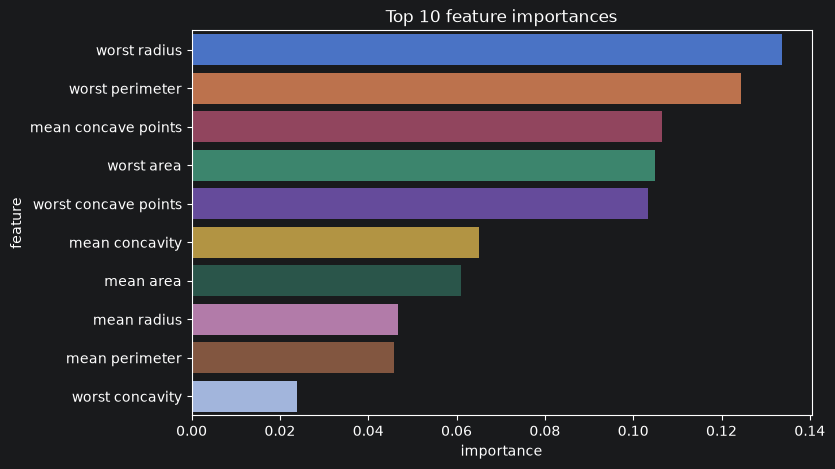

In [25]:
rf_clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    max_features='sqrt',
    oob_score=True
)

rf_clf.fit(X_train, y_train)

rf_y_pred = rf_clf.predict(X_test)

print("학습셋 : ", rf_clf.score(X_train, y_train))
print("평가셋 : ", rf_clf.score(X_test, y_test))
print("OOB Score : ", rf_clf.oob_score_)

feature_importance_df = pd.DataFrame({

    'feature': cancer.feature_names,
    'importance': rf_clf.feature_importances_

}).sort_values('importance', ascending=False)

display(feature_importance_df.head(10))

plt.figure(figsize=(8, 5))
sns.barplot(
    data=feature_importance_df.head(10),
    x='importance',
    y='feature',
    hue='feature',
    legend=False
)
plt.title('Top 10 feature importances')
plt.xlabel('importance')
plt.ylabel('feature')
plt.show()


## 문제 5. RandomForestRegressor 회귀 모델 학습

Diabetes 데이터로 RandomForestRegressor를 학습하고 회귀 지표를 확인하세요.

### 요구사항
- `load_diabetes(as_frame=True)` 사용
- `test_size=0.2`, `random_state=42`
- `RandomForestRegressor(n_estimators=300, max_depth=5, random_state=42, n_jobs=1)` 사용
- 평가셋 R2, RMSE 출력

### 실행 결과
```text
평가셋 R2: 약 0.4574
평가셋 RMSE: 약 53.6192
```


In [24]:
diabetes = load_diabetes(as_frame=True)

reg_X = diabetes.data
reg_y = diabetes.target

reg_X_train, reg_X_test, reg_y_train, reg_y_test = train_test_split(
    reg_X,
    reg_y,
    test_size=0.2,
    random_state=42
)

rf_reg = RandomForestRegressor(
    n_estimators=300,
    max_depth=5,
    random_state=42,
    n_jobs=1
)

rf_reg.fit(reg_X_train, reg_y_train)

reg_pred = rf_reg.predict(reg_X_test)

print("평가셋 R2 : ", rf_reg.score(reg_X_test, reg_y_test))
print("평가셋 RMSE : ", root_mean_squared_error(reg_y_test, reg_pred))

평가셋 R2 :  0.4573543689863395
평가셋 RMSE :  53.61920270555988
